In [3]:
import pandas as pd

# Load datasets
train_df = pd.read_csv("train (1).csv")
test_df = pd.read_csv("test (1).csv")

# === 1. Check for Missing Values ===
print("Missing values in train dataset:")
print(train_df.isnull().sum())
print("\nMissing values in test dataset:")
print(test_df.isnull().sum())

# === 2. Remove Duplicates ===
print(f"\nDuplicate rows in train dataset: {train_df.duplicated().sum()}")
print(f"Duplicate rows in test dataset: {test_df.duplicated().sum()}")

# Remove duplicates if any
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

# === 3. Summary statistics for outlier detection ===
print("\nTrain dataset summary statistics:")
print(train_df.describe())


Missing values in train dataset:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Missing values in test dataset:
id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64

Duplicate rows in train dataset: 0
Duplicate rows in test dataset: 0

Train dataset summary statistics:
     

In [4]:
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# --- Step 1: Outlier Detection using Z-score ---
# We'll exclude the target column ('price_range' assumed) from z-score
# Modify this if your target column is named differently

target_col = 'price_range'  # <-- change if needed
feature_cols = [col for col in train_df.columns if col != target_col and col != 'id']

# Calculate Z-scores
z_scores = train_df[feature_cols].apply(zscore)

# Keep only rows with Z-score < 3 for all features
train_df = train_df[(z_scores < 3).all(axis=1)]

# --- Step 2: Normalization (Min-Max) ---
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])  # Apply same transform to test

# --- Step 3: Train/Validation/Test Split (60/20/20) ---
train_set, temp_set = train_test_split(train_df, test_size=0.4, random_state=42, stratify=train_df[target_col])
valid_set, test_set = train_test_split(temp_set, test_size=0.5, random_state=42, stratify=temp_set[target_col])

# --- Optional: Reset index ---
train_set.reset_index(drop=True, inplace=True)
valid_set.reset_index(drop=True, inplace=True)
test_set.reset_index(drop=True, inplace=True)

# Confirm shapes
print("Train set:", train_set.shape)
print("Validation set:", valid_set.shape)
print("Test set:", test_set.shape)


Train set: (1192, 21)
Validation set: (398, 21)
Test set: (398, 21)


In [5]:
import pandas as pd
import os
from scipy.io import arff

# === 1. Save to CSV ===
train_set.to_csv("train_clean.csv", index=False)
valid_set.to_csv("valid_clean.csv", index=False)
test_set.to_csv("test_clean.csv", index=False)
test_df.to_csv("test_raw_scaled.csv", index=False)  # For submission/test usage

print("CSV files saved.")

# === 2. Convert CSV to ARFF ===
def csv_to_arff(csv_path, arff_path, relation_name="data"):
    df = pd.read_csv(csv_path)

    # Ensure class column is categorical
    if 'price_range' in df.columns:
        df['price_range'] = df['price_range'].astype('category')

    with open(arff_path, "w") as f:
        f.write(f"@relation {relation_name}\n\n")
        for col in df.columns:
            if col == 'price_range':
                unique_vals = sorted(df[col].unique())
                arff_vals = ",".join([str(int(val)) for val in unique_vals])
                f.write(f"@attribute {col} {{{arff_vals}}}\n")
            else:
                f.write(f"@attribute {col} numeric\n")
        f.write("\n@data\n")
        df.to_csv(f, index=False, header=False)


# Convert all CSV files to ARFF
csv_to_arff("train_clean.csv", "train_clean.arff", "train")
csv_to_arff("valid_clean.csv", "valid_clean.arff", "validation")
csv_to_arff("test_clean.csv", "test_clean.arff", "test")

print("ARFF files saved.")


CSV files saved.
ARFF files saved.


Dataset shape: (1192, 21)

Data Types:
 battery_power    float64
blue             float64
clock_speed      float64
dual_sim         float64
fc               float64
four_g           float64
int_memory       float64
m_dep            float64
mobile_wt        float64
n_cores          float64
pc               float64
px_height        float64
px_width         float64
ram              float64
sc_h             float64
sc_w             float64
talk_time        float64
three_g          float64
touch_screen     float64
wifi             float64
price_range        int64
dtype: object

Summary Statistics:
        battery_power         blue  clock_speed     dual_sim           fc  \
count    1192.000000  1192.000000  1192.000000  1192.000000  1192.000000   
mean        0.473493     0.501678     0.415503     0.508389     0.256169   
std         0.290946     0.500207     0.332196     0.500139     0.251613   
min         0.000000     0.000000     0.000000     0.000000     0.000000   
25%         0.21509

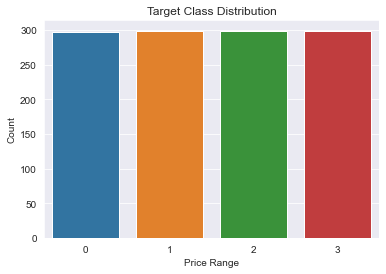

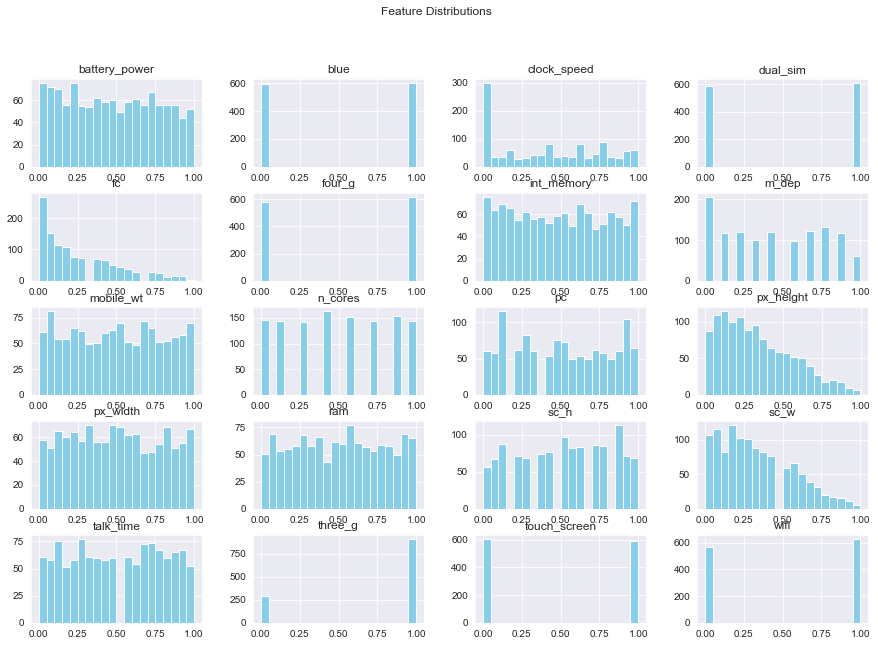

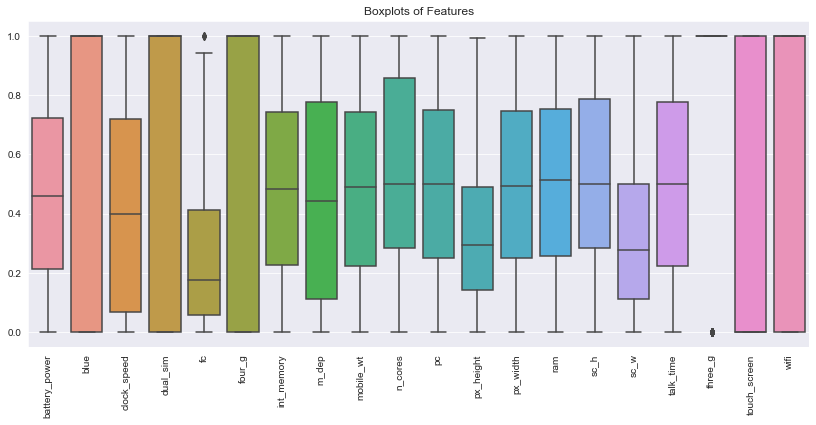

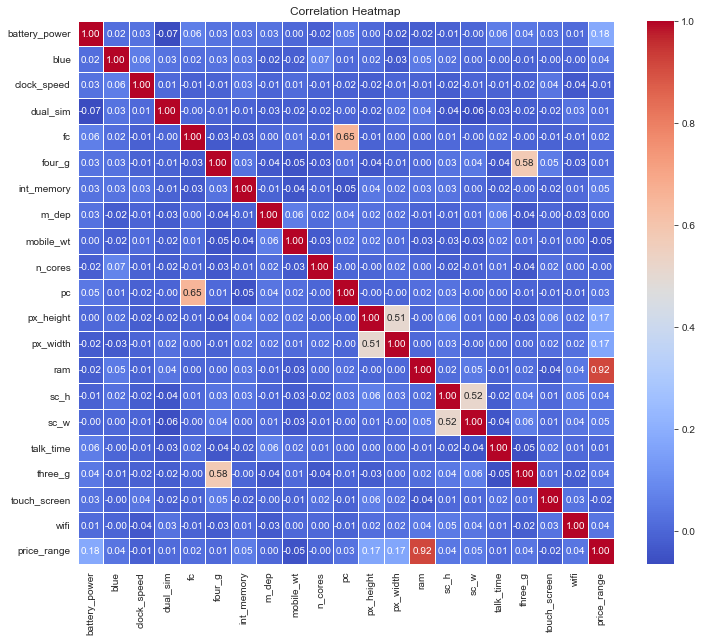


Skewness of numeric features:
 battery_power    0.076390
blue            -0.006720
clock_speed      0.154333
dual_sim        -0.033604
fc               0.942515
four_g          -0.057142
int_memory       0.061523
m_dep            0.083242
mobile_wt        0.024152
n_cores         -0.013178
pc              -0.002935
px_height        0.639989
px_width         0.049085
ram             -0.001011
sc_h            -0.109121
sc_w             0.601314
talk_time       -0.027793
three_g         -1.219528
touch_screen     0.020161
wifi            -0.094182
dtype: float64


In [10]:

# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the cleaned dataset
# Replace this with the correct path if needed
df = pd.read_csv('train_clean.csv')  # Use your actual cleaned CSV file name

# 3. Overview of dataset
print("Dataset shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

# 4. Class Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df)
plt.title('Target Class Distribution')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

# 5. Feature Distributions
df.drop(columns=['price_range']).hist(bins=20, figsize=(15, 10), color='skyblue')
plt.suptitle('Feature Distributions')
plt.show()

# 6. Boxplot to Detect Outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=['price_range']))
plt.xticks(rotation=90)
plt.title('Boxplots of Features')
plt.show()

# 7. Correlation Matrix
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 8. Skewness (Optional)
skewness = df.drop(columns=['price_range']).skew()
print("\nSkewness of numeric features:\n", skewness)

